# Imports
 

In [1]:
import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import time
import joblib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

import seaborn as sns



# Reading CSV

In [2]:
df = pd.read_csv("Crimes_-_2022.csv")
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,12592454,JF113025,1/14/2022 15:55,067XX S MORGAN ST,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,False,True,...,16.0,68,26,1170805.0,1860170.0,2022,9/14/2023 15:41,41.771782,-87.649437,"(41.771782439, -87.649436929)"
1,12785595,JF346553,8/5/2022 21:00,072XX S UNIVERSITY AVE,1544,SEX OFFENSE,SEXUAL EXPLOITATION OF A CHILD,APARTMENT,True,False,...,5.0,69,17,1185135.0,1857211.0,2022,9/14/2023 15:41,41.763338,-87.597001,"(41.763337967, -87.597001131)"
2,12808281,JF373517,8/14/2022 14:00,055XX W ARDMORE AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,RESIDENCE,False,False,...,39.0,11,17,1138383.0,1937953.0,2022,9/14/2023 15:41,41.985875,-87.766404,"(41.985875279, -87.766403857)"
3,12888104,JF469015,11/10/2022 3:47,072XX S MAY ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,STREET,False,False,...,17.0,68,15,1169903.0,1856822.0,2022,9/14/2023 15:41,41.762615,-87.652840,"(41.76261474, -87.652840463)"
4,13209277,JG422539,8/15/2022 9:00,0000X W JACKSON BLVD,810,THEFT,OVER $500,COMMERCIAL / BUSINESS OFFICE,False,False,...,4.0,32,6,NaN,NaN,2022,9/14/2023 15:43,NaN,NaN,NaN


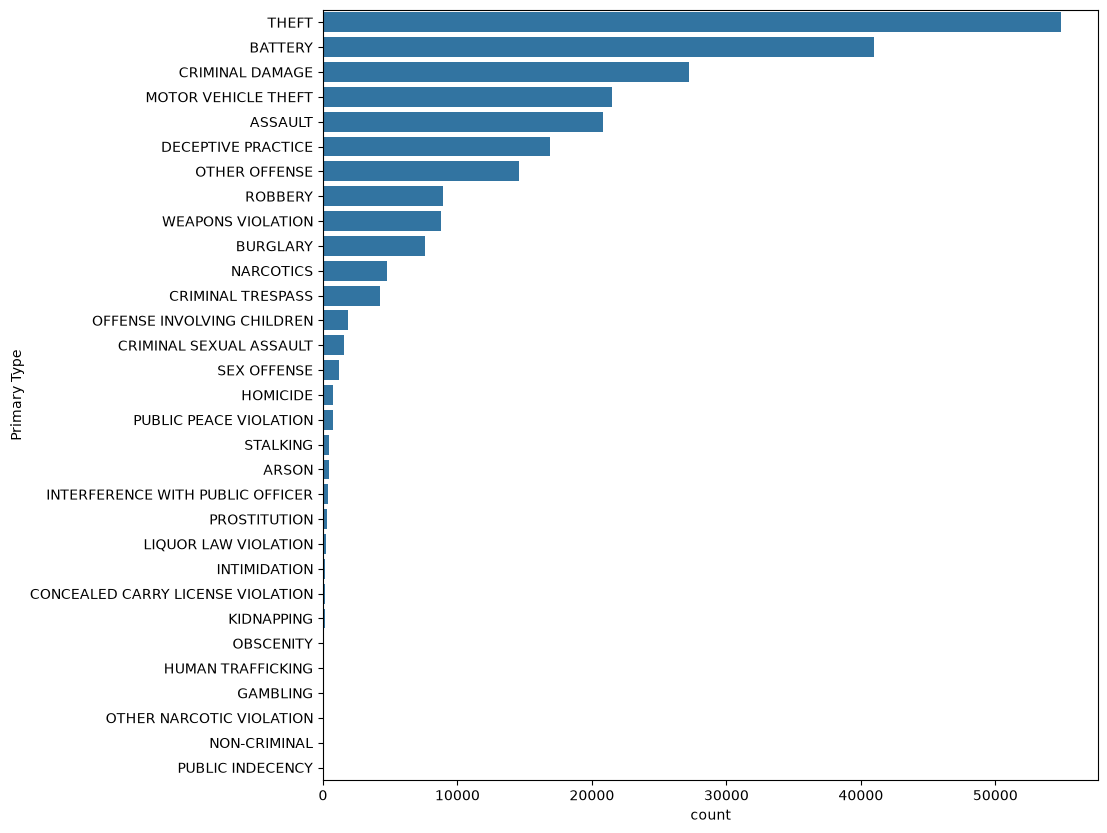

In [3]:
crime_count = df['Primary Type'].value_counts().rename('count').reset_index()
fig,ax = plt.subplots(figsize=(10,10))
sns.barplot(crime_count, y='Primary Type',x='count')
plt.show()

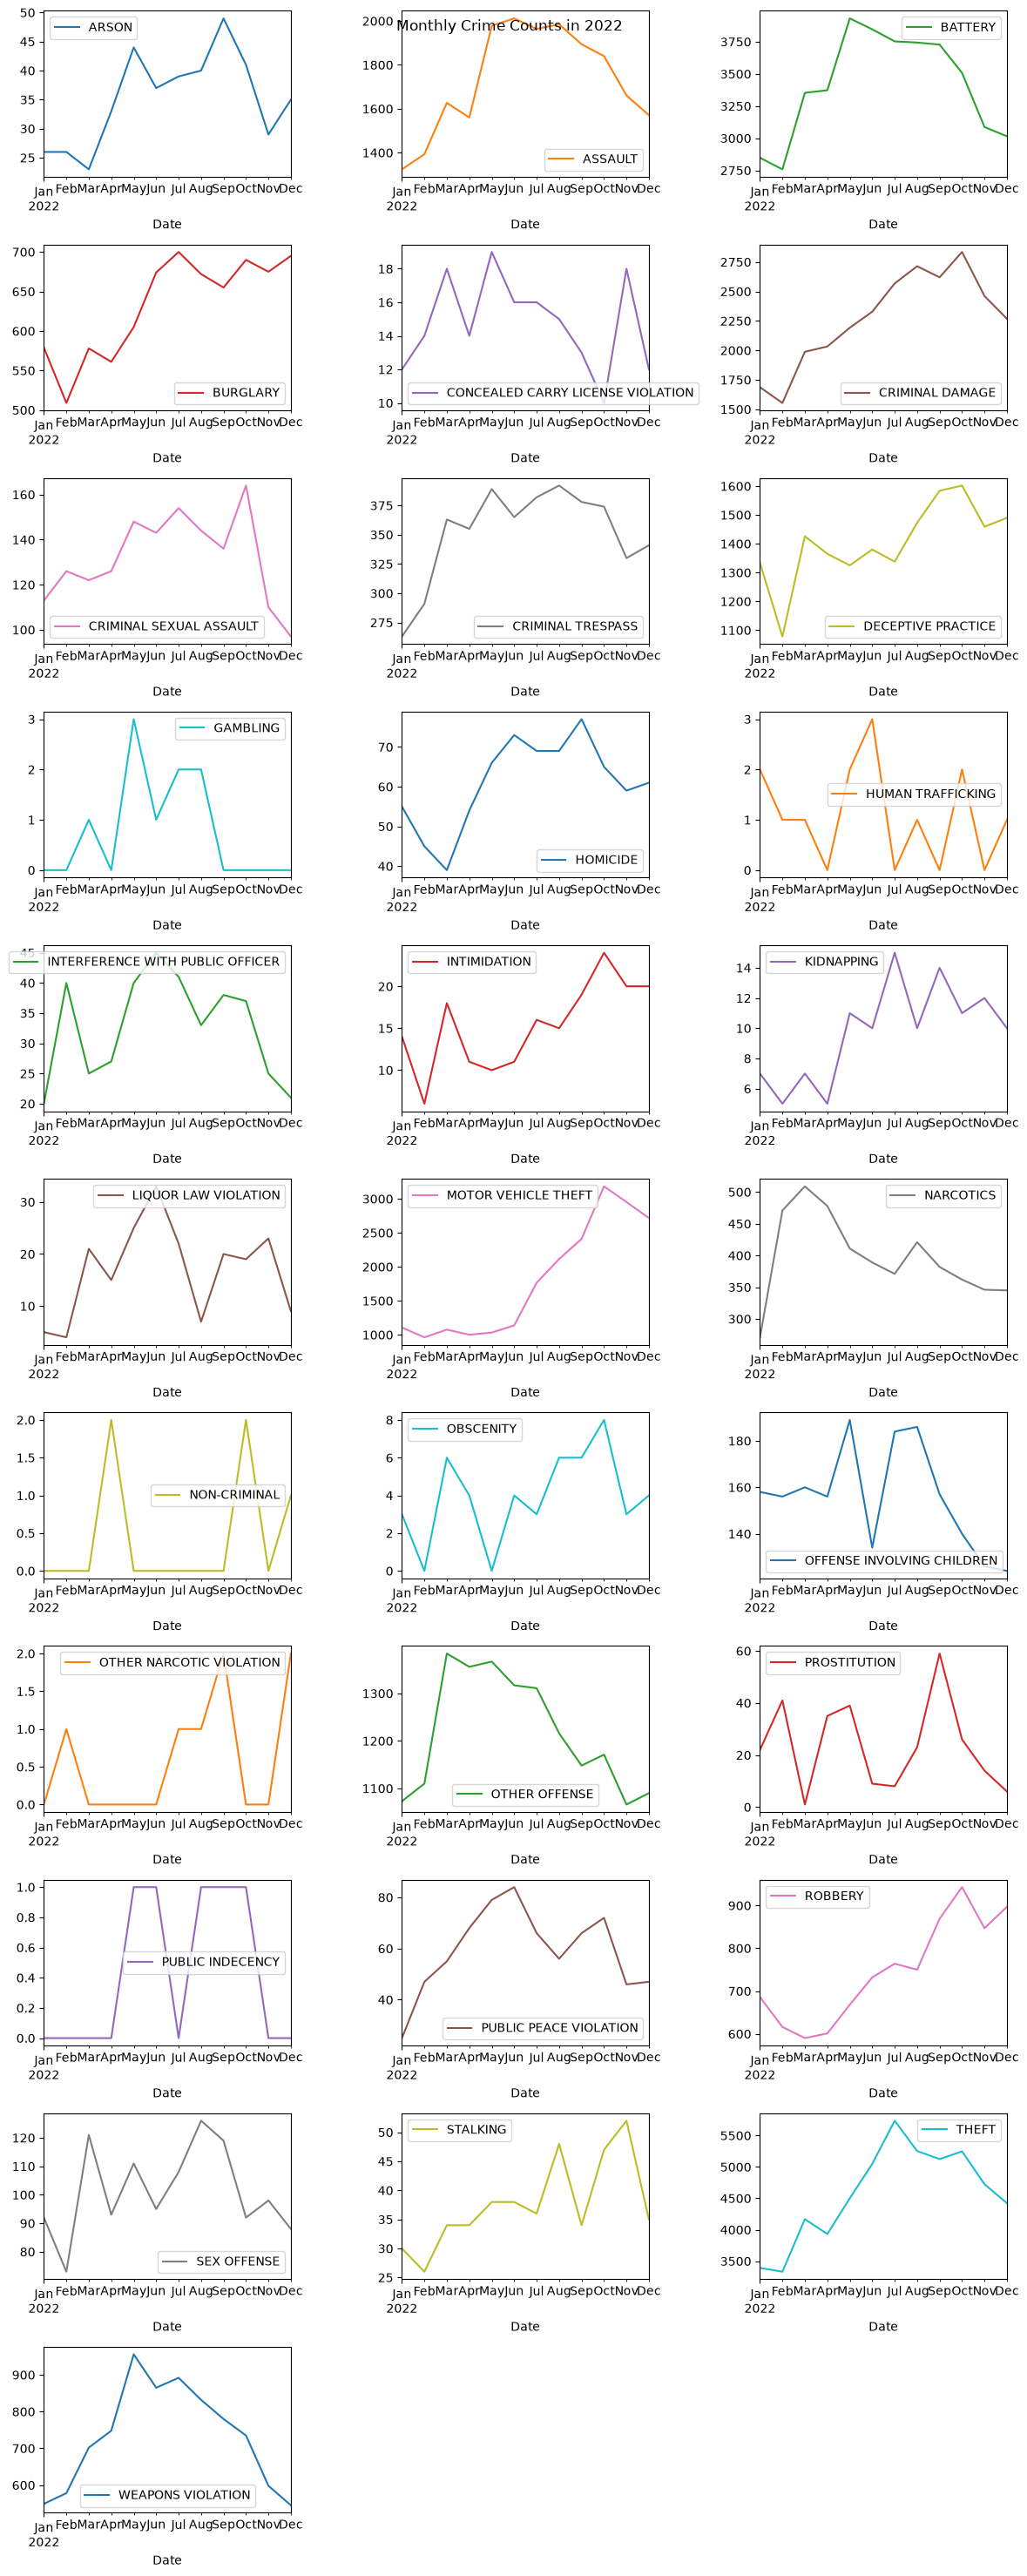

In [4]:
# Ensure 'Date' column is datetime (if not already)
df['Date'] = pd.to_datetime(df['Date'])

# Filter for only 2022 (in case your dataset has other years too)
df_2022 = df[df['Date'].dt.year == 2022]

# Group by month and Primary Type
crimes_count_month = df_2022.pivot_table(
    values='ID',
    index=df_2022['Date'].dt.to_period('M').dt.to_timestamp(),
    columns='Primary Type',
    aggfunc='size',
    fill_value=0
)

# Plot
plot = crimes_count_month.plot(
    figsize=(12, 30),
    subplots=True,
    layout=(-1, 3),
    sharex=False,
    sharey=False,
    title='Monthly Crime Counts in 2022'
)

plt.tight_layout()
plt.show()

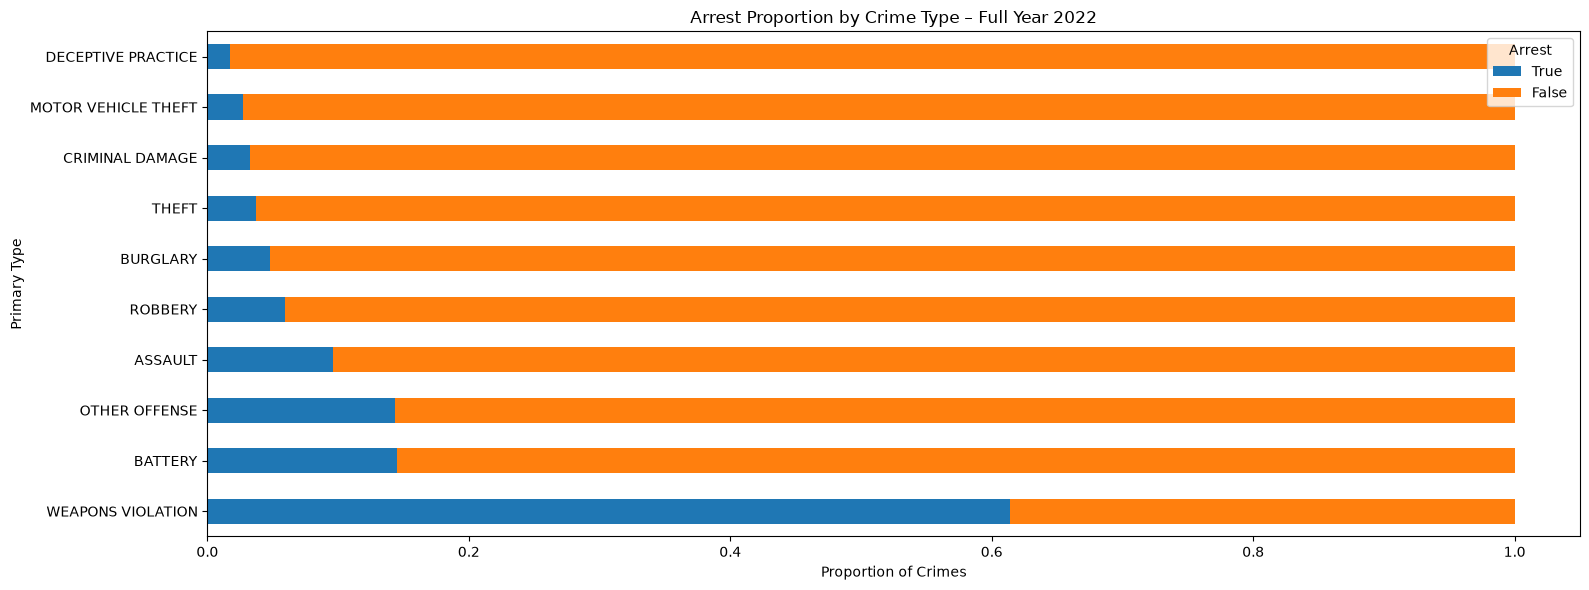

In [5]:

df = pd.read_csv("Crimes_-_2022.csv")
plot_df = df.copy()  # Copy to avoid modifying original


# Ensure Date column is in datetime format
plot_df['Date'] = pd.to_datetime(plot_df['Date'], errors='coerce')

# Filter data for the year 2022
plot_df_2022 = plot_df[plot_df['Date'].dt.year == 2022]

# Check if data exists after filtering
if plot_df_2022.empty:
    print("Error: No data available for 2022 after filtering.")
    exit(1)

# Get top 10 most frequent crime types
primary_types = plot_df_2022['Primary Type'].value_counts().head(10).index.tolist()

# Filter to only include those top crime types
plot_df_2022 = plot_df_2022[plot_df_2022['Primary Type'].isin(primary_types)]

# Group by Primary Type and Arrest status for the full year
arrest_data = plot_df_2022.groupby(['Primary Type', 'Arrest']).size().reset_index(name='No. of Crimes')

# Pivot the data
pivot = arrest_data.pivot_table(
    index='Primary Type',
    columns='Arrest',
    values='No. of Crimes',
    fill_value=0
).reset_index()

# Calculate proportions
pivot['Total'] = pivot[True] + pivot[False]
pivot['Arrested'] = pivot[True] / pivot['Total']
pivot['Not Arrested'] = pivot[False] / pivot['Total']

# Select only needed columns and sort
plot_data = pivot[['Primary Type', 'Arrested', 'Not Arrested']].set_index('Primary Type')
plot_data = plot_data.sort_values('Arrested', ascending=False)

# Plot horizontal stacked bar chart
ax = plot_data.plot(
        kind='barh',
        stacked=True,
        figsize=(16, 6),
        color=['#1f77b4', '#ff7f0e'],  # Blue = Arrested, Orange = Not Arrested
        title='Arrest Proportion by Crime Type – Full Year 2022'
    )
plt.xlabel('Proportion of Crimes')
plt.legend(title='Arrest', labels=['True', 'False'], loc='upper right')
plt.tight_layout()
plt.show()


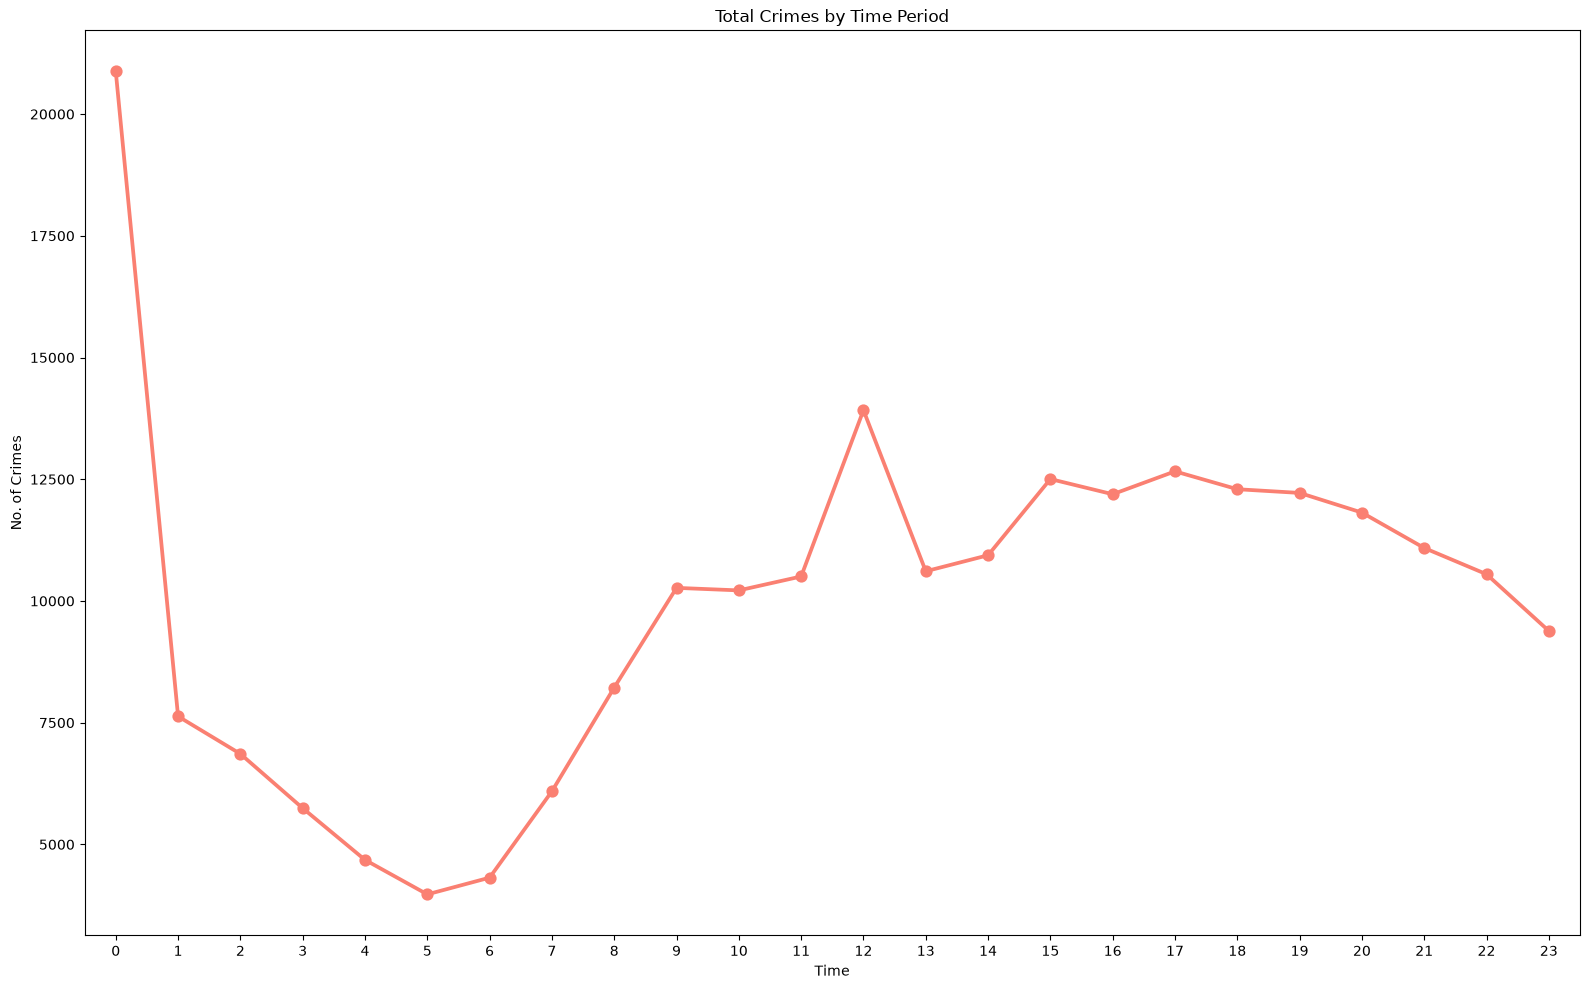

In [6]:
# Read original CSV and create a copy
df = pd.read_csv("Crimes_-_2022.csv")
plot_df = df.copy()  # Copy to avoid modifying original

# Ensure Date column is in datetime format and extract hours
plot_df['Date'] = pd.to_datetime(plot_df['Date'])
plot_df['hours'] = plot_df['Date'].dt.hour

# Group by hour to count crimes
crimes_by_time = plot_df.groupby('hours').size().reset_index(name='No. of Crimes')

# Create the point plot
fig = plt.figure(figsize=(16, 10))
sns.pointplot(data=crimes_by_time, x="hours", y="No. of Crimes", color="salmon")

plt.xlabel('Time')
plt.ylabel('No. of Crimes')
plt.title('Total Crimes by Time Period')
plt.tight_layout()
plt.show()

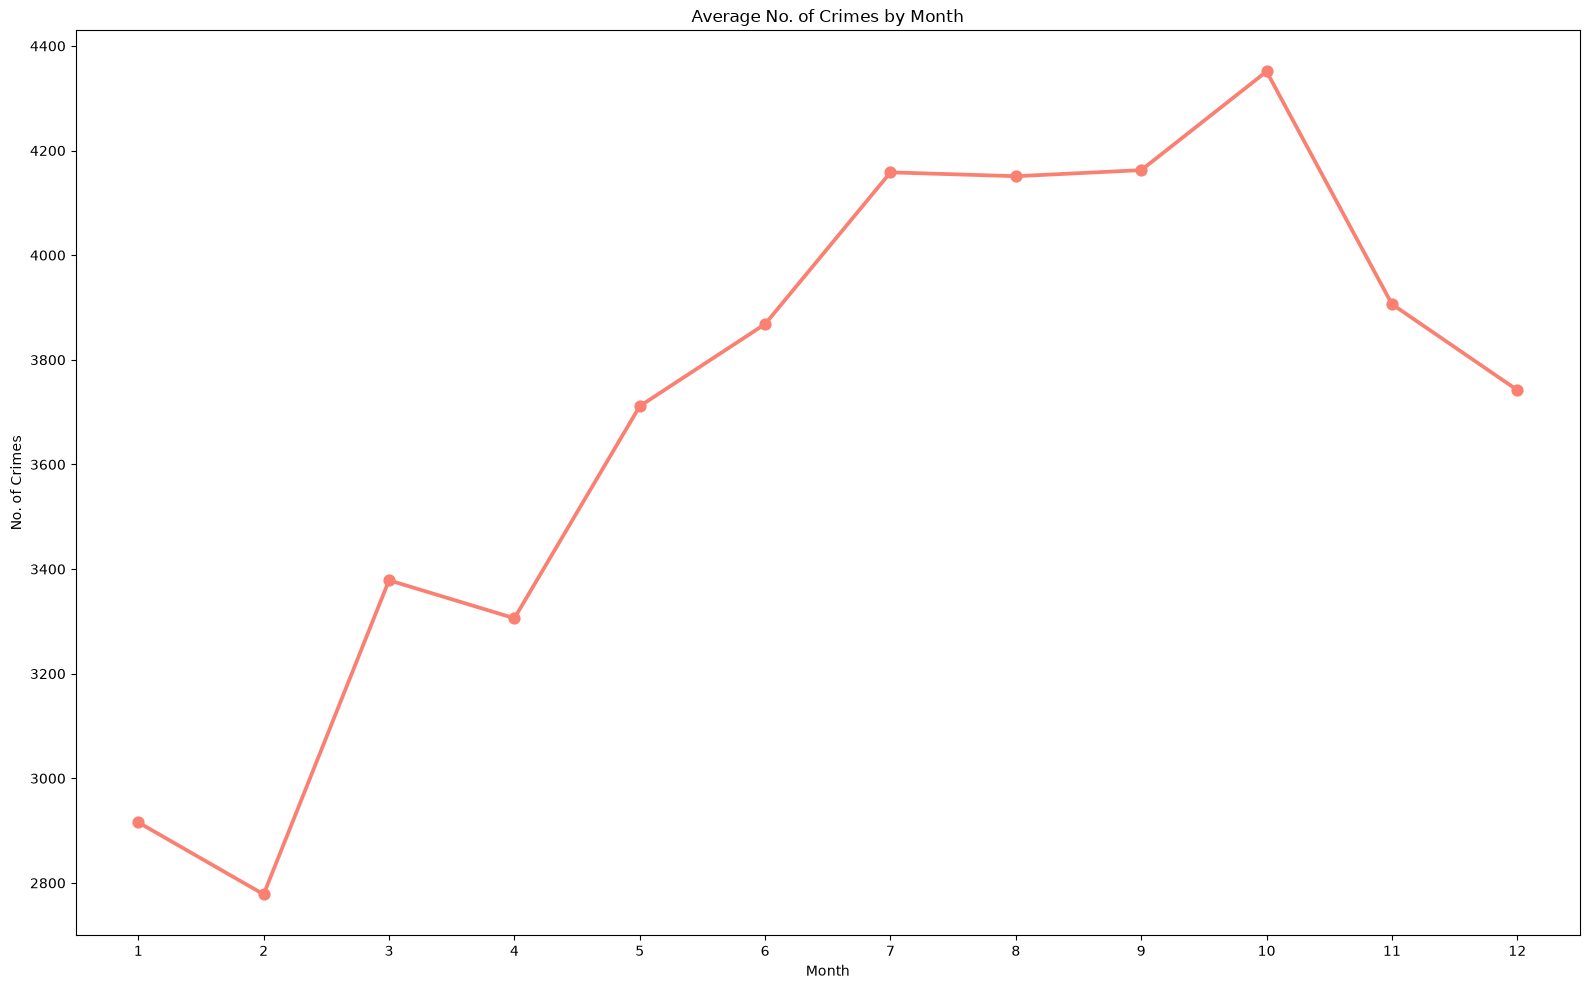

In [7]:
# Read original CSV and create a copy
df = pd.read_csv("Crimes_-_2022.csv")
plot_df = df.copy()  # Copy to avoid modifying original

# Ensure Date column is in datetime format and extract month
plot_df['Date'] = pd.to_datetime(plot_df['Date'])
plot_df['month'] = plot_df['Date'].dt.month

# Get top 10 most frequent crime types
primary_types = plot_df['Primary Type'].value_counts().head(10).index.tolist()

# Filter to only include those top crime types
crimes_by_month = plot_df[plot_df['Primary Type'].isin(primary_types)]

# Group by month to count crimes
crimes_by_month = crimes_by_month.groupby('month').size().reset_index(name='No. of Crimes')

# Divide each monthly total by 5 years to get the average crime count
crimes_by_month['month (average)'] = crimes_by_month['No. of Crimes'].apply(lambda x: x / 5)

# Plot crimes by month
fig = plt.figure(figsize=(16, 10))
sns.pointplot(data=crimes_by_month, x='month', y='month (average)', color="salmon")

# Set labels and title
plt.xlabel('Month')
plt.ylabel('No. of Crimes')
plt.title('Average No. of Crimes by Month')
plt.tight_layout()
plt.show()

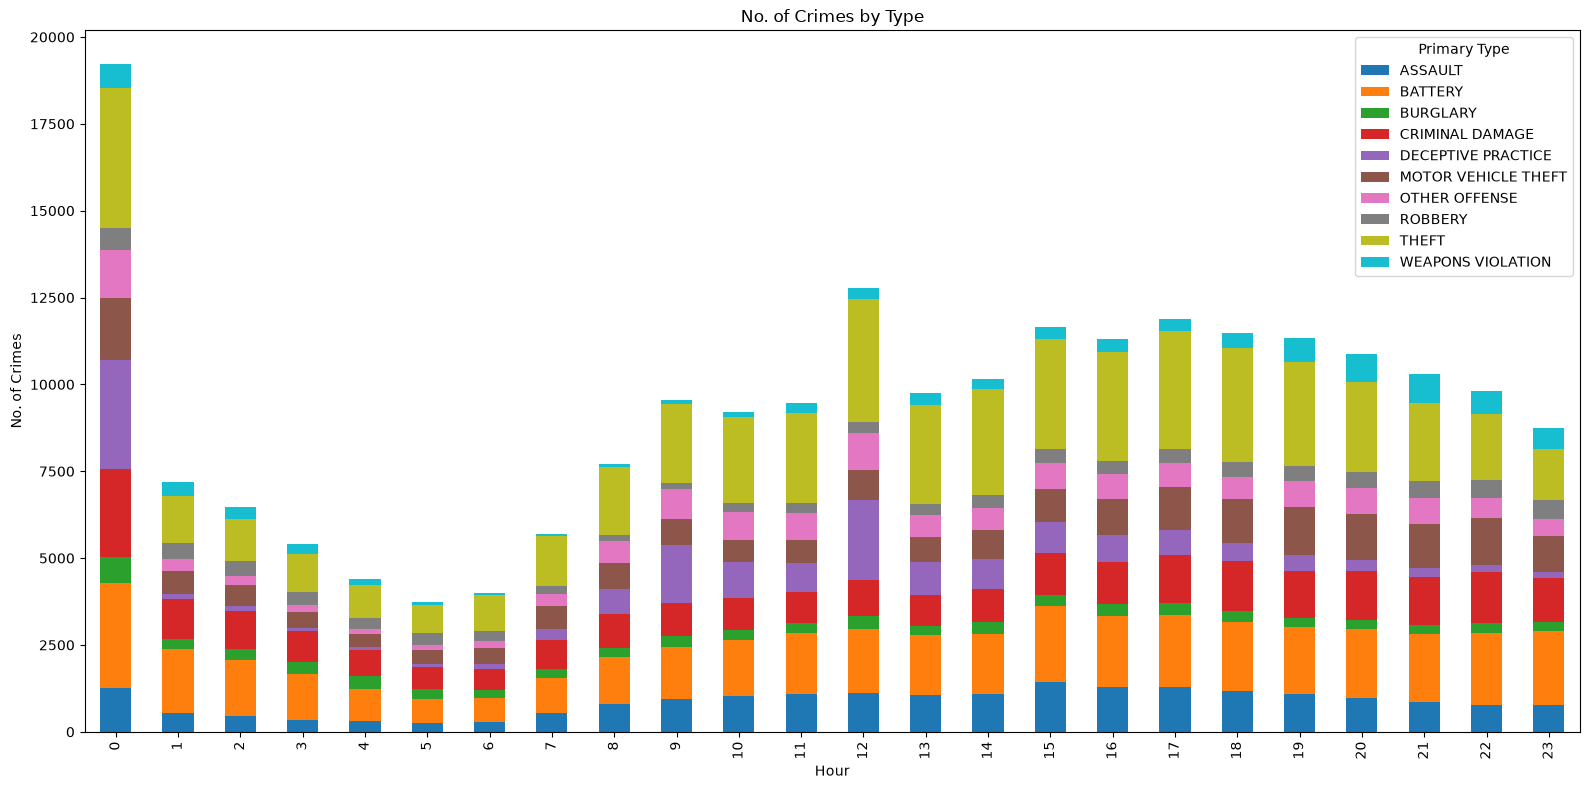

In [8]:
# Read original CSV and create a copy
df = pd.read_csv("Crimes_-_2022.csv")
crimes_by_type = df.copy()  # Copy to avoid modifying original

# Ensure Date column is in datetime format and extract hour
crimes_by_type['Date'] = pd.to_datetime(crimes_by_type['Date'])
crimes_by_type['time_hour'] = crimes_by_type['Date'].dt.hour

# Get top 10 most frequent crime types
primary_types = crimes_by_type['Primary Type'].value_counts().head(10).index.tolist()

# Filter to only include those top crime types
crimes_by_type = crimes_by_type[crimes_by_type['Primary Type'].isin(primary_types)]

# Group crimes by type and hour
crimes_by_type = crimes_by_type.groupby(['time_hour', 'Primary Type']).size().reset_index(name='No. of Crimes')

# Format hour data
crimes_by_type['hours'] = crimes_by_type['time_hour'].apply(lambda x: str(x) + ':00')

# Create crime type pivot table
crimes_by_type_pivot = pd.pivot_table(crimes_by_type, index=['time_hour'], columns=['Primary Type'], values='No. of Crimes', aggfunc=np.sum)

# Create stacked bar chart of crime types, compared hourly
crimes_by_type_pivot.plot(kind='bar', stacked=True, figsize=(16, 8), title="No. of Crimes by Type")
plt.xlabel('Hour')
plt.ylabel('No. of Crimes')
plt.tight_layout()
plt.show()

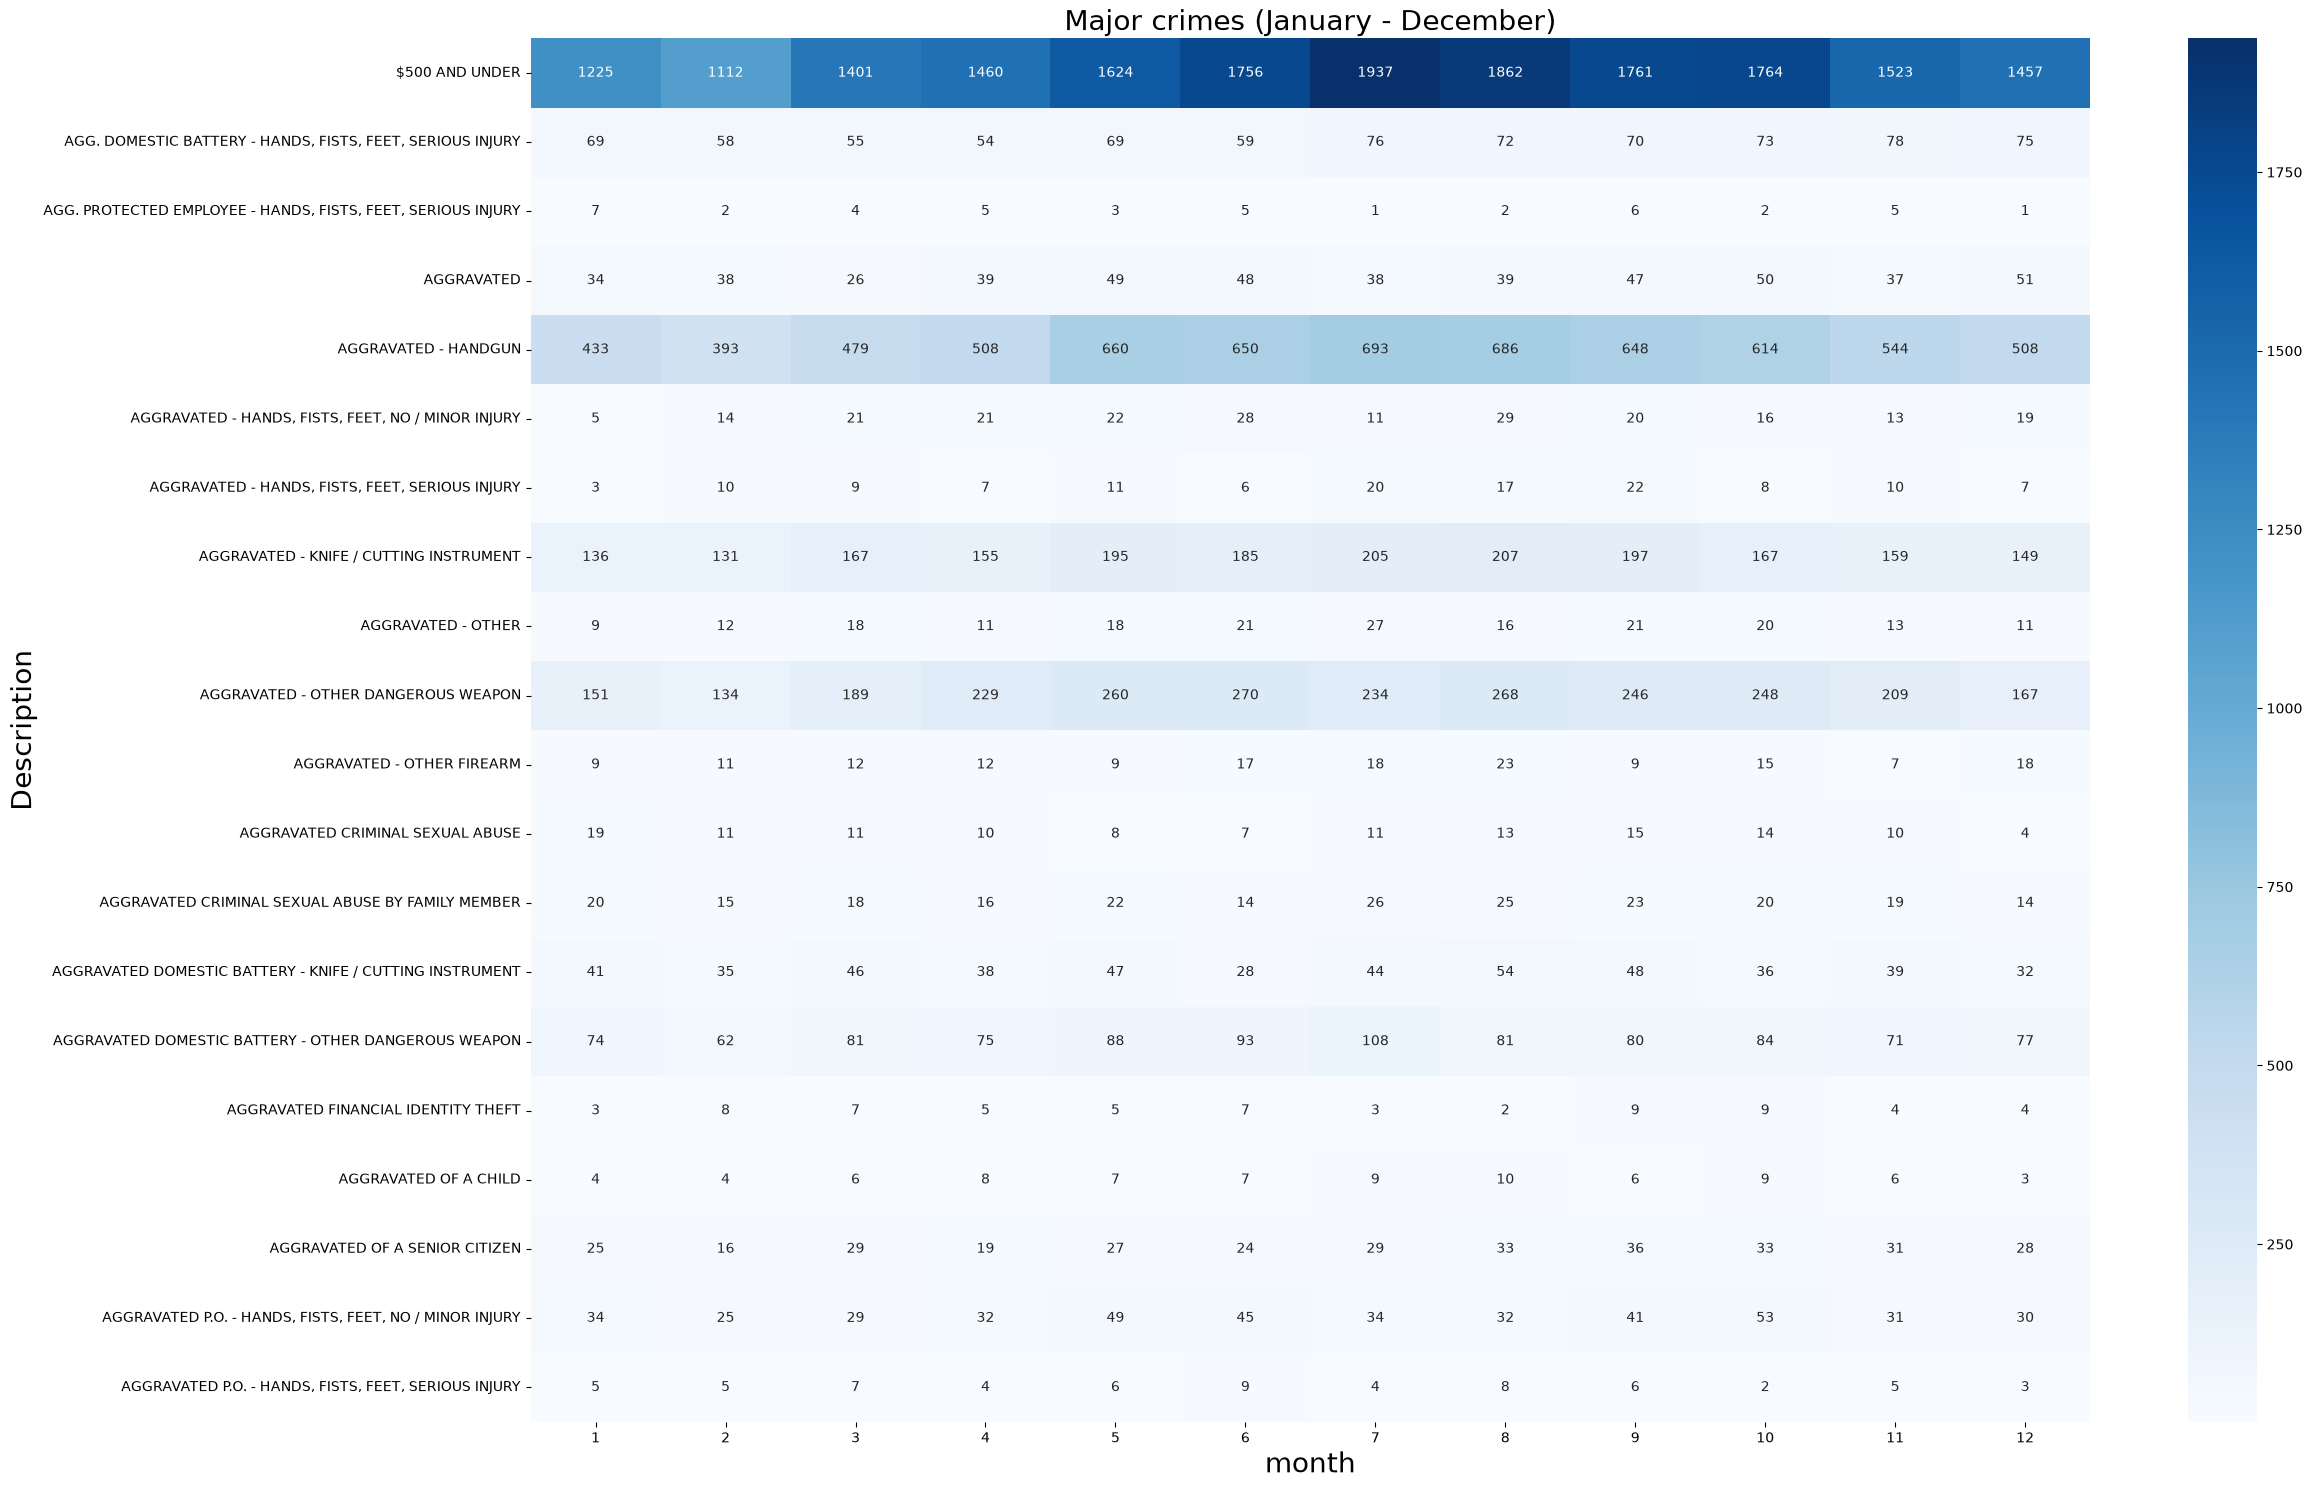

In [9]:
df = pd.read_csv("Crimes_-_2022.csv")
df2 = df.copy()  # Copy to avoid modifying original

# Ensure Date column is in datetime format and extract month
df2['Date'] = pd.to_datetime(df2['Date'])
df2['month'] = df2['Date'].dt.month

# Group crimes by Description and month, counting Arrest
df2 = df2.groupby(['Description', 'month'])['Arrest'].count()

# Chart formatting
DIMS = (25, 15)
fig = plt.figure(figsize=DIMS)
ax1 = fig.add_subplot(111)
ax1.set_title('Major crimes (January - December)', fontsize=20)
ax1.set_ylabel('Details', fontsize=20)
ax1.set_xlabel('month', fontsize=20)

# Get top 20 data
df2 = pd.DataFrame(df2).reset_index()
top_crimes = df2['Description'].value_counts().head(20).index.tolist()
df2 = df2[df2['Description'].isin(top_crimes)]

# Pivot data to 2D table, and fill all NA values
df2 = df2.pivot_table(index='Description', columns='month', values='Arrest')
df2.fillna(0, inplace=True)

# Create heatmap
sns.heatmap(df2, cmap="Blues", annot=True, fmt='g')

plt.tight_layout()
plt.show()

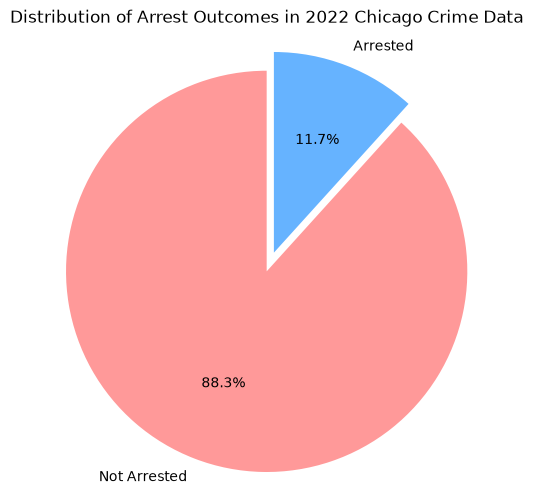

In [10]:
df['Arrest'] = df['Arrest'].astype(int)

arrest_counts = df['Arrest'].value_counts()
labels = ['Not Arrested', 'Arrested']
sizes = [arrest_counts.get(0, 0), arrest_counts.get(1, 0)]
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Arrest Outcomes in 2022 Chicago Crime Data')
plt.axis('equal')
plt.show()

# DateFrame Info

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239558 entries, 0 to 239557
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    239558 non-null  int64  
 1   Case Number           239558 non-null  str    
 2   Date                  239558 non-null  str    
 3   Block                 239558 non-null  str    
 4   IUCR                  239558 non-null  str    
 5   Primary Type          239558 non-null  str    
 6   Description           239558 non-null  str    
 7   Location Description  238593 non-null  str    
 8   Arrest                239558 non-null  int64  
 9   Domestic              239558 non-null  bool   
 10  Beat                  239558 non-null  int64  
 11  District              239558 non-null  int64  
 12  Ward                  239548 non-null  float64
 13  Community Area        239558 non-null  int64  
 14  FBI Code              239558 non-null  str    
 15  X Coordinat

# Date Preprocessing

# Check for Duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

# Check For Null 

In [13]:
df.isnull().sum()

ID                         0
Case Number                0
Date                       0
Block                      0
IUCR                       0
Primary Type               0
Description                0
Location Description     965
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                      10
Community Area             0
FBI Code                   0
X Coordinate            4667
Y Coordinate            4667
Year                       0
Updated On                 0
Latitude                4667
Longitude               4667
Location                4667
dtype: int64

# Handelling Missing Values

In [14]:
df['Location Description'] = df['Location Description'].fillna('UNKNOWN')
df['Ward'] = df['Ward'].fillna(df['Ward'].mode()[0])
for col in ['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude',]:
    df[col] = df[col].fillna(df[col].median())

# Drop irrelevant Columns

In [15]:
df.drop(columns=['ID', 'Case Number', 'Updated On', 'Location'], inplace=True)

# Encoding Non-Numerical Data

In [16]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)  
df['Hour'] = df['Date'].dt.hour
df['Weekday'] = df['Date'].dt.weekday
df['Month'] = df['Date'].dt.month
df.drop(columns=['Date'], inplace=True)

In [17]:
categorical_cols = ['Block', 'IUCR', 'Primary Type', 'Description', 
                    'Location Description', 'FBI Code']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [18]:
df['Arrest'] = df['Arrest'].astype(int)
df['Domestic'] = df['Domestic'].astype(int)

In [19]:
df.head()

,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Latitude,Longitude,Hour,Weekday,Month
0,22436,167,22,129,102,0,1,724,7,16.0,68,20,1170805.0,1860170.0,2022,41.771782,-87.649437,15,4,1
1,23282,85,27,229,17,1,0,324,3,5.0,69,13,1185135.0,1857211.0,2022,41.763338,-87.597001,21,4,8
2,19518,87,27,13,102,0,0,1621,16,39.0,11,13,1138383.0,1937953.0,2022,41.985875,-87.766404,14,6,8
3,23245,69,30,216,119,0,0,733,7,17.0,68,11,1169903.0,1856822.0,2022,41.762615,-87.652840,3,3,11
4,449,284,29,183,45,0,0,113,1,4.0,32,23,1167256.0,1893383.0,2022,41.863073,-87.661465,9,0,8


In [20]:
X = df.drop(columns=['Arrest'])
y = df['Arrest']

# Decision Tree Algorithm

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
model = DecisionTreeClassifier(min_samples_leaf=20,random_state=42)

In [24]:
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()
print (end_time-start_time)

1.725034475326538


In [25]:
y_pred = model.predict(X_test)

In [26]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100}%")

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     42301
           1       0.82      0.50      0.63      5611

    accuracy                           0.93     47912
   macro avg       0.88      0.75      0.79     47912
weighted avg       0.92      0.93      0.92     47912

Accuracy: 92.94122558023042%


In [27]:
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[41697   604]
 [ 2778  2833]]


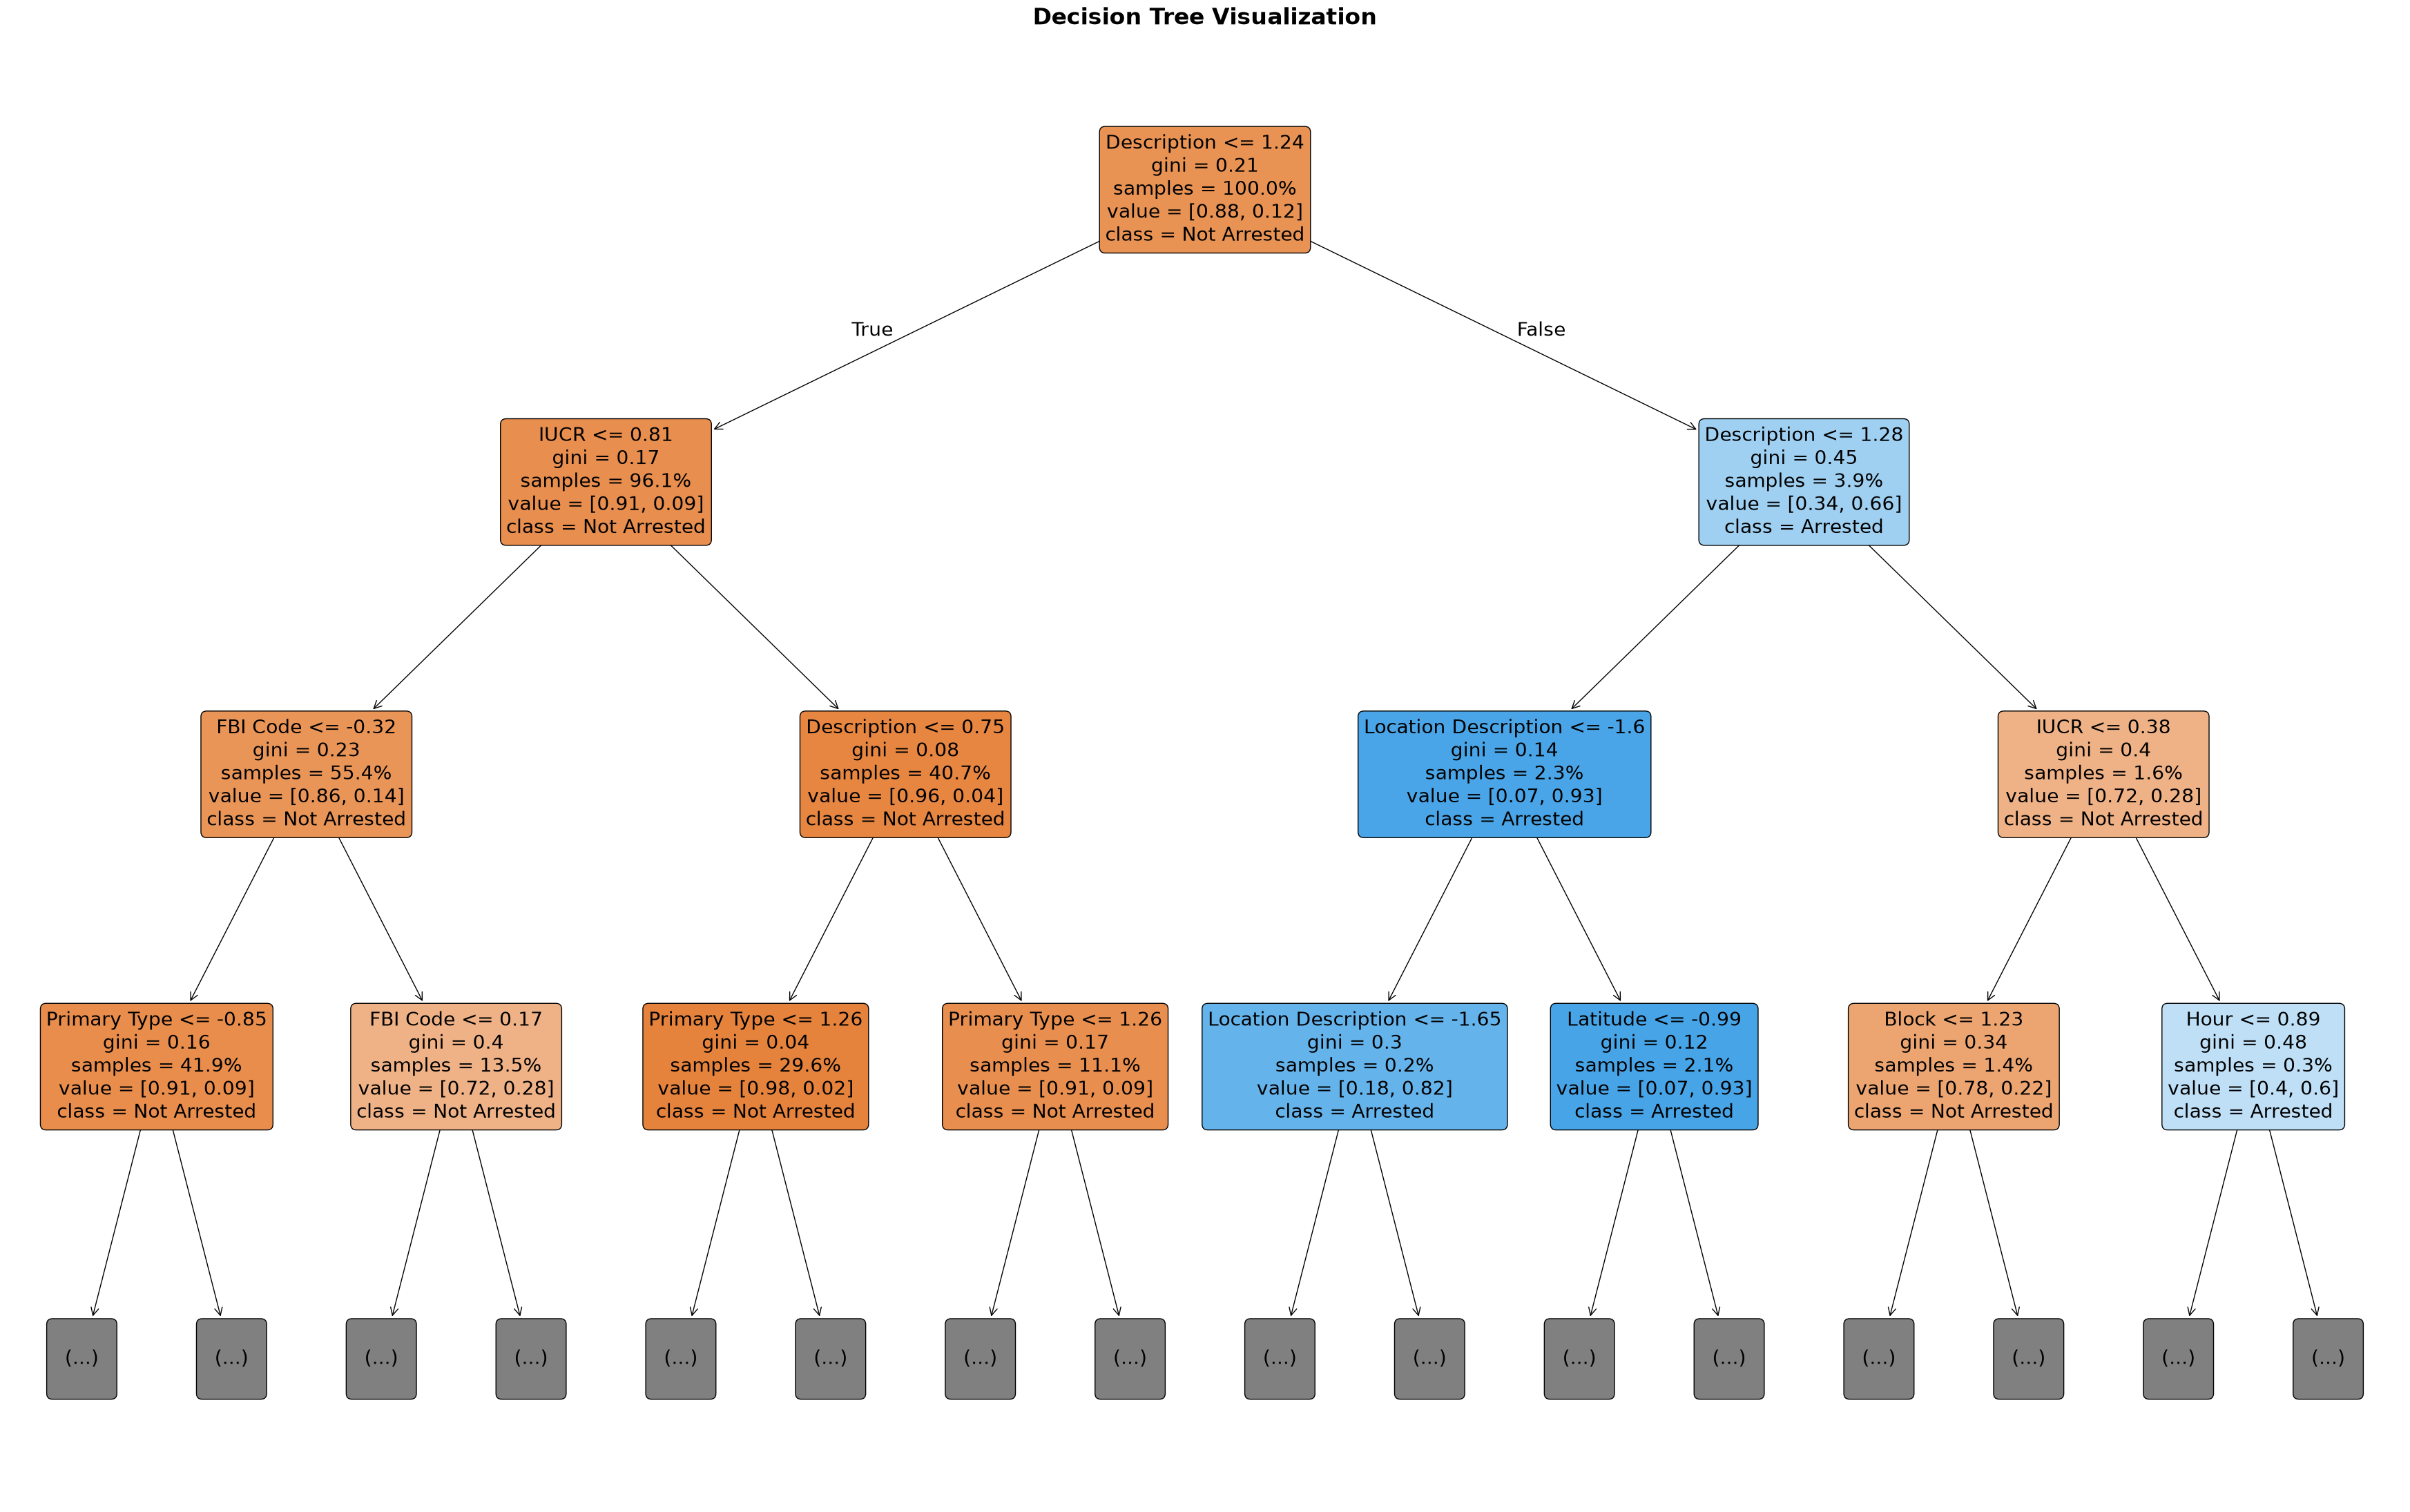

In [29]:
plt.figure(figsize=(35, 22))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Arrested", "Arrested"],
    filled=True,
    rounded=True,
    fontsize=20,      
    max_depth=3,
    proportion=True,
    precision=2
)

plt.title("Decision Tree Visualization", fontsize=24, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# K-Nearest Neighbors (KNN) Algorithm

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [33]:
y_pred = knn.predict(X_test)
y_pred_prob_knn = knn.predict_proba(X_test)[:, 1] 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy * 100}%")

Accuracy: 0.9042202371013525
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     42269
           1       0.64      0.43      0.51      5643

    accuracy                           0.90     47912
   macro avg       0.78      0.70      0.73     47912
weighted avg       0.89      0.90      0.90     47912

Confusion Matrix:
 [[40908  1361]
 [ 3228  2415]]
Accuracy: 92.94122558023042%


# Logistic Regression Algorithm

In [34]:
X_train_df = pd.DataFrame(X_train)  # Convert to DataFrame
Y_train_df = pd.DataFrame(y_train)
X_small = X_train_df.sample(n=40000, random_state=42)
Y_small = Y_train_df.sample(n=40000,random_state = 42)
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [35]:
# Predict class (0 or 1)
y_pred = logmodel.predict(X_test)

# Predict probability
y_prob = logmodel.predict_proba(X_test)[:, 1]  # Probability of arrest (class 1)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy * 100}%")


Accuracy: 0.8842878610786442
Confusion Matrix:
 [[42244    25]
 [ 5519   124]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94     42269
           1       0.83      0.02      0.04      5643

    accuracy                           0.88     47912
   macro avg       0.86      0.51      0.49     47912
weighted avg       0.88      0.88      0.83     47912

Accuracy: 92.94122558023042%


# Support Vector Machine (SVM) Algorithm

In [56]:
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train, y_train)

c:\Users\fayro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [57]:
y_pred_small = svm.predict(X_test)
y_pred_prob_svm = svm.predict_proba(X_test)[:, 1] 
print("Accuracy:", accuracy_score(y_test, y_pred_small))
print("Classification Report:\n", classification_report(y_test, y_pred_small))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_small))
print(f"Accuracy: {accuracy * 100}%")

Accuracy: 0.9206044414760394
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96     42269
           1       0.89      0.37      0.53      5643

    accuracy                           0.92     47912
   macro avg       0.91      0.68      0.74     47912
weighted avg       0.92      0.92      0.91     47912

Confusion Matrix:
 [[42005   264]
 [ 3540  2103]]
Accuracy: 92.94122558023042%


In [ ]:
joblib.dump(knn, 'knn.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(svm,'svm.joblib')